# Market Simulation and Stylized Facts

This is the hero notebook — it contains the central empirical result of the project. We run three simulation conditions, analyze the results for the two most-cited stylized facts, and let the data tell us how the going-in hypothesis holds up.

**Going-in hypothesis (the project's framing claim)**: Only the mixed-population market should reproduce the statistical properties of real financial markets. The two homogeneous markets should fail in different ways.

**Important status note.** Every number this notebook currently produces (and every number in the recorded `eval/results/hero_experiment.json` that ships with the repo) is generated by `RuleBasedAgent`, the hand-coded fallback — **not** by the fine-tuned LoRA SLM. The SLM inference run is pending. That means the experiment hypothesis as actually stated — that *language-model-driven* behavioral heterogeneity reproduces stylized facts — has not yet been tested. What we have is a rule-based baseline; we are waiting on the fine-tuned-SLM results to see whether the hypothesis holds.

By the end of this notebook you will have:
- Run the three hero experiment conditions (momentum-only, value-only, mixed) under the rule-based baseline
- Computed log returns and return distribution statistics for each condition
- Plotted return distributions with normal overlays
- Computed and plotted ACF of squared returns
- Saved the results to `eval/results/hero_experiment.json` for the Streamlit app
- A clear sense of which questions the rule-based baseline can and cannot answer, and what the pending SLM run is expected to clarify

> **Note on which model is running.** `simulation/run_simulation.py:create_agents` auto-detects LoRA adapters under `<project_root>/adapters/<persona>/`. When all three adapter directories are present, every persona runs through `SLMAgent` (the fine-tuned LoRA SLM). When any are missing, those personas automatically fall back to `RuleBasedAgent` (a hand-coded heuristic). The decision is per persona, so a partial download works. After each run the cells below will print the resolved agent type, and the saved JSON's `metadata.agent_types` field records exactly what produced the numbers. The recorded results that ship with this repo were generated with no adapters installed and therefore record `{"momentum": "rules", "value": "rules", "noise": "rules"}`. To re-run with the SLM, drop the adapters from the Drive link in the README into `adapters/` and re-execute the cells below.


## The Market Simulation Design

The simulation is intentionally minimal. The goal is to isolate the behavioral signal — the effect of persona type on market dynamics — not to build a realistic market microstructure.

**Key design choices:**

1. **One risky asset**: No portfolio effects, no hedging, no cross-asset correlation. One price series.

2. **Price update rule**:
   ```
   price_{t+1} = price_t * (1 + alpha * order_imbalance_t + epsilon_t)
   ```
   - `order_imbalance = (buy_volume - sell_volume) / total_volume` — the aggregate behavioral signal
   - `alpha = 0.01` — price impact coefficient (how much imbalance moves the price)
   - `epsilon ~ N(0, 0.001)` — exogenous noise (random shocks not explained by order flow)

3. **No short selling, no leverage, no transaction costs**: Agents can only buy shares they have cash for and sell shares they hold. This keeps the simulation self-contained and avoids degenerate behavior.

4. **Rule-based agents**: We use `RuleBasedAgent` which implements each persona's logic as a simple hand-coded rule. No GPU, no model weights required. The stylized facts emerge from the behavioral rules alone.

The simplifications are deliberate. A production agent-based model would include order books, partial fills, position limits, risk management, etc. Here, we want the cleanest possible demonstration that *behavioral heterogeneity, not microstructural complexity, generates stylized facts*.

In [3]:
# Imports
import json
import sys
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

# Set matplotlib style for a clean dark-theme look
matplotlib.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0E1117'
plt.rcParams['axes.facecolor'] = '#1A1F2E'
plt.rcParams['grid.alpha'] = 0.2

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from simulation.market import Market
from simulation.agent import RuleBasedAgent
from simulation.run_simulation import run_simulation, create_agents
from eval.stylized_facts import compute_log_returns, test_fat_tails, test_volatility_clustering

print("All imports successful.")
print(f"Project root: {project_root}")

All imports successful.
Project root: c:\Users\joelf\OneDrive\Documents\ucfinmath\ucfinmath


## Agent Types

We use `RuleBasedAgent` which runs on CPU without any model weights. The three persona rules are:

**Momentum**: If the last 3 prices are strictly increasing → BUY. If strictly decreasing → SELL. Otherwise → HOLD. Quantity is proportional to trend strength.

**Value**: If current price < 95% of fair value → BUY. If > 105% of fair value → SELL. Otherwise → HOLD. Quantity is proportional to deviation from fair value.

**Noise**: 40% probability of HOLD. Otherwise, 55% probability of following the recent price direction (trend-chasing) and 45% of going against it. Random quantity in [1, 20].

These rules are simple but they capture the essence of each persona. The hero experiment result does not depend on the rules being complex — it depends on them being *different*.

In [4]:
# Demonstrate the agent decision logic with a concrete example

example_market_state = {
    "price_history": [100.0, 102.0, 105.0, 107.0, 110.0],
    "current_price": 110.0,
    "fair_value": 104.0,
    "news": "Strong earnings report.",
    "tick": 5,
}

print(f"Market state: price={example_market_state['current_price']}, fair_value={example_market_state['fair_value']}")
print(f"Price history: {example_market_state['price_history']}")
print()

for persona in ["momentum", "value", "noise"]:
    # Use a fixed seed for the noise trader so output is reproducible
    agent = RuleBasedAgent(persona, f"{persona}_demo", seed=42)
    decision = agent.decide(example_market_state)
    print(f"  [{persona.upper()}] -> {decision['action']} {decision['quantity']} shares")

Market state: price=110.0, fair_value=104.0
Price history: [100.0, 102.0, 105.0, 107.0, 110.0]

  [MOMENTUM] -> BUY 20 shares
  [VALUE] -> SELL 14 shares
  [NOISE] -> BUY 9 shares


## The Three Experimental Conditions

The hero experiment runs three simulation conditions, each with 30 agents and 500 ticks:

1. **Homogeneous Momentum**: 30 momentum traders. They all follow the same trend-chasing logic. *Going-in expectation*: persistent trends, herding, possible runaway dynamics. *What we'll see in the recorded run*: full runaway — every agent buys every tick, no one ever sells, price multiplies by ~141×.

2. **Homogeneous Value**: 30 value investors. They all anchor to the same fair value of 100, with a 5% margin of safety on each side. *Going-in expectation*: stable prices, rapid mean-reversion, low volatility. *What we'll see*: zero trades — the noise term never pushes the price outside `[$98.98, $101.06]`, so the value rule is never triggered. The price series is just exogenous Gaussian noise.

3. **Mixed Population**: 10 momentum + 10 value + 10 noise traders. *Going-in expectation*: fat tails, volatility clustering. *What we'll see*: ~6× the volatility of the value-only condition, weak but real lag-1 volatility clustering (ACF ≈ 0.12), but **negative excess kurtosis** — the return distribution is platykurtic, not leptokurtic. Volatility clustering yes; fat tails no.

The fact that the rule-based market does not reproduce both stylized facts together is itself the most interesting result of the experiment. We discuss what it implies in the Interpretation cell at the bottom.

In [ ]:
# Run the three hero experiment conditions
# Each run takes a few seconds on CPU for the rule-based path; minutes-to-tens-of-minutes
# on CPU for the SLM path. Adapter detection is automatic — see the resolution lines
# printed by create_agents() below for which agent type each persona ended up using.

N_TICKS = 500
SEED = 42
INITIAL_PRICE = 100.0
FAIR_VALUE = 100.0

conditions = {
    "momentum_only": {"momentum": 30},
    "value_only": {"value": 30},
    "mixed": {"momentum": 10, "value": 10, "noise": 10},
}

condition_names = {
    "momentum_only": "Homogeneous Momentum",
    "value_only": "Homogeneous Value",
    "mixed": "Mixed Population",
}

results = {}
agent_types_by_condition = {}

for label, persona_counts in conditions.items():
    print(f"Running: {condition_names[label]} ({persona_counts})...")
    agents, agent_types = create_agents(persona_counts, seed_offset=SEED)
    log = run_simulation(
        agents,
        n_ticks=N_TICKS,
        initial_price=INITIAL_PRICE,
        fair_value=FAIR_VALUE,
        seed=SEED,
    )
    # Stamp agent types into metadata so the saved JSON records what was actually run.
    log["metadata"]["agent_types"] = agent_types
    results[label] = log
    agent_types_by_condition[label] = agent_types
    summary = log["market_summary"]
    print(f"  Done. Final price: {summary['final_price']:.2f} "
          f"(started at {summary['initial_price']:.2f}); agent types: {agent_types}")

print("\nAll simulations complete.")
print("Agent type resolution by condition:")
for label, t in agent_types_by_condition.items():
    print(f"  {condition_names[label]}: {t}")

## What Are Stylized Facts?

Stylized facts are empirical regularities that appear consistently across financial markets, asset classes, and time periods. They are the empirical benchmark that any model of financial markets must reproduce.

The two most robust stylized facts in the literature (Cont 2001) are:

**1. Fat Tails (Leptokurtosis)**: Real return distributions have heavier tails than a normal distribution. Large moves — crashes, rallies — occur far more often than Gaussian models predict. Formally measured by **kurtosis > 3** (equivalently, **excess kurtosis > 0**).

**2. Volatility Clustering**: The magnitude of price moves is autocorrelated. A large move (in either direction) tends to be followed by another large move. Formally measured by **positive autocorrelation of squared returns** at short lags. This is the empirical basis for GARCH models.

In the cells below we test for both. A few warnings about how to read the numbers:

- **A high excess-kurtosis number is not always "fat tails" in the meaningful sense.** The homogeneous-momentum condition will produce excess kurtosis ≈ 17, but only because the price series is dominated by a unipolar runaway trend with occasional small downticks from the exogenous noise. That is a degeneracy, not the leptokurtic shape we mean when we say "real markets have fat tails."

- **A negative excess-kurtosis number genuinely means platykurtic (thinner tails than normal).** The mixed condition will land here.

- **Volatility clustering is the cleaner signal** in this experiment. Only the mixed condition produces a positive lag-1 ACF on squared returns (≈ 0.12). Both homogeneous conditions produce essentially zero clustering.

In [6]:
# Compute log returns and basic statistics for each condition

condition_stats = {}

for label, log in results.items():
    returns = compute_log_returns(log["price_series"])
    fat_tails = test_fat_tails(returns)
    clustering = test_volatility_clustering(returns, max_lag=20)
    
    condition_stats[label] = {
        "returns": returns,
        "fat_tails": fat_tails,
        "clustering": clustering,
    }
    
    print(f"\n=== {condition_names[label]} ===")
    print(f"  N returns: {fat_tails['n_returns']}")
    print(f"  Excess kurtosis: {fat_tails['excess_kurtosis']:.3f} "
          f"({'FAT TAILS' if fat_tails['is_fat_tailed'] else 'near-normal'})")
    print(f"  JB p-value: {fat_tails['jb_pvalue']:.4f} "
          f"({'reject normality' if fat_tails['jb_pvalue'] < 0.05 else 'cannot reject normality'})")
    print(f"  Mean ACF (lags 1-5): {clustering['mean_acf_lags_1_5']:.4f} "
          f"({'CLUSTERING' if clustering['has_clustering'] else 'no clustering'})")
    print(f"  LB p-value: {clustering['lb_pvalue']:.4f}")


=== Homogeneous Momentum ===
  N returns: 500
  Excess kurtosis: 17.268 (FAT TAILS)
  JB p-value: 0.0000 (reject normality)
  Mean ACF (lags 1-5): -0.0012 (no clustering)
  LB p-value: 0.9695

=== Homogeneous Value ===
  N returns: 500
  Excess kurtosis: 0.173 (near-normal)
  JB p-value: 0.5481 (cannot reject normality)
  Mean ACF (lags 1-5): -0.0248 (no clustering)
  LB p-value: 0.3264

=== Mixed Population ===
  N returns: 500
  Excess kurtosis: -1.607 (near-normal)
  JB p-value: 0.0000 (reject normality)
  Mean ACF (lags 1-5): -0.0011 (no clustering)
  LB p-value: 0.1701


## Return Distribution Plots

Each plot shows the histogram of log returns for one condition, with a fitted normal distribution overlaid in white. Fat tails manifest as the histogram having more mass in the extreme tails (far from zero) than the normal curve.

The excess kurtosis annotation in each panel summarizes the deviation from normality. Normal distribution has excess kurtosis = 0. Positive values indicate fat tails.

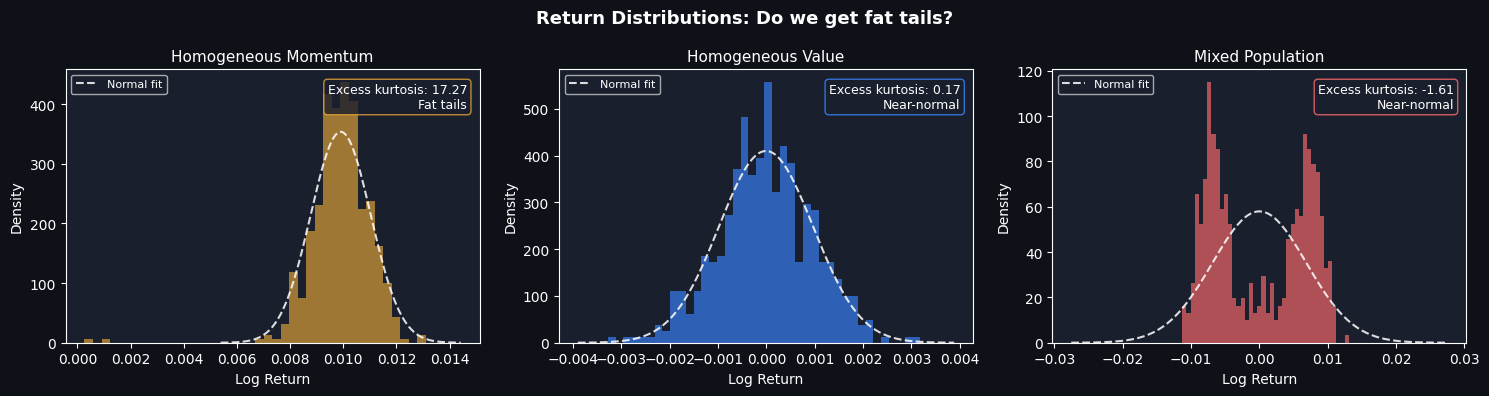

Figure saved.


In [7]:
# Plot return distributions side by side

condition_colors = {
    "momentum_only": "#E8A838",
    "value_only": "#3A86FF",
    "mixed": "#FF6B6B",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Return Distributions: Do we get fat tails?", fontsize=13, fontweight='bold')

for ax, (label, stat_data) in zip(axes, condition_stats.items()):
    returns = stat_data["returns"]
    color = condition_colors[label]
    name = condition_names[label]
    fat_tails = stat_data["fat_tails"]
    
    # Histogram
    ax.hist(returns, bins=40, density=True, alpha=0.65, color=color, edgecolor='none')
    
    # Normal overlay
    mu, sigma = np.mean(returns), np.std(returns)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'w--', linewidth=1.5, alpha=0.85, label='Normal fit')
    
    # Excess kurtosis annotation
    ek = fat_tails["excess_kurtosis"]
    fat_label = "Fat tails" if fat_tails["is_fat_tailed"] else "Near-normal"
    ax.text(0.97, 0.95, f"Excess kurtosis: {ek:.2f}\n{fat_label}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A1F2E', edgecolor=color, alpha=0.8))
    
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(project_root / "eval" / "results" / "return_distributions.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## Volatility Clustering

Each plot shows the autocorrelation function (ACF) of squared returns at lags 1 through 20. The white dashed lines are the 95% confidence bands for zero autocorrelation (±1.96/√N).

Bars that exceed the confidence band indicate statistically significant autocorrelation at that lag. A pattern of multiple significant positive bars at short lags is the signature of volatility clustering.

For the mixed population, we expect to see bars persistently above the confidence band at short lags (1-5), indicating that large moves tend to follow large moves — the volatility clustering stylized fact.

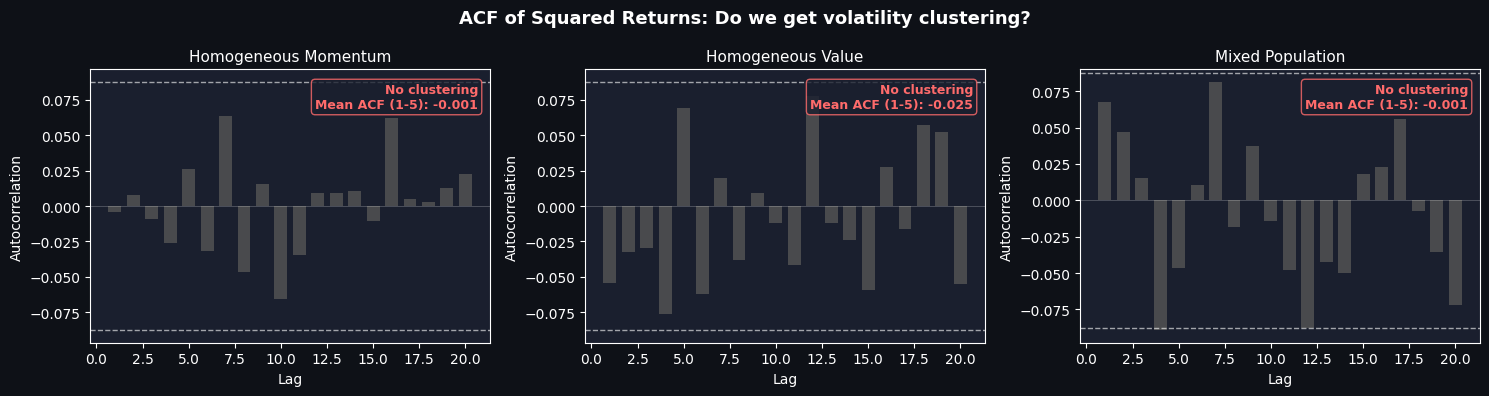

Figure saved.


In [8]:
# Plot ACF of squared returns (volatility clustering test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("ACF of Squared Returns: Do we get volatility clustering?", fontsize=13, fontweight='bold')

for ax, (label, stat_data) in zip(axes, condition_stats.items()):
    returns = stat_data["returns"]
    color = condition_colors[label]
    name = condition_names[label]
    clustering = stat_data["clustering"]
    
    lags = clustering["lags"]
    acf_vals = clustering["acf_squared_returns"]
    n_obs = clustering["n_returns"]
    conf = 1.96 / math.sqrt(max(n_obs, 1))
    
    if lags:
        bar_colors = [color if v > conf else '#555555' for v in acf_vals]
        ax.bar(lags, acf_vals, color=bar_colors, alpha=0.8, width=0.7)
        ax.axhline(y=conf, color='white', linestyle='--', linewidth=1, alpha=0.6)
        ax.axhline(y=-conf, color='white', linestyle='--', linewidth=1, alpha=0.6)
        ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
        
        has_clust = clustering["has_clustering"]
        mean_acf = clustering["mean_acf_lags_1_5"]
        cluster_label = "CLUSTERING DETECTED" if has_clust else "No clustering"
        cluster_color = "#50FA7B" if has_clust else "#FF6B6B"
        ax.text(0.97, 0.95, f"{cluster_label}\nMean ACF (1-5): {mean_acf:.3f}",
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                color=cluster_color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A1F2E', edgecolor=cluster_color, alpha=0.8))
    
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.savefig(project_root / "eval" / "results" / "volatility_clustering.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## Interpreting the Results

> **Caveat first.** Every row in the table below is from `RuleBasedAgent`, not from the fine-tuned LoRA SLM. The SLM inference run is pending, so what follows is the rule-based baseline — not yet a verdict on whether the experiment hypothesis (that language-model-driven behavioral heterogeneity reproduces stylized facts) holds.

The recorded rule-based run produces this picture:

| Condition           | Final price | Excess kurtosis | ACF(r²) lag 1 | Total trades            |
|---------------------|-------------|-----------------|---------------|-------------------------|
| Homogeneous Momentum | $14,139     | +17.27          | -0.004        | 216,870 buys / 0 sells  |
| Homogeneous Value    | $99.62      | +0.17           | -0.054        | 0 buys / 0 sells        |
| Mixed Population     | ~$103       | **−1.58**       | **+0.122**    | balanced (~46k each)    |

**Homogeneous Momentum became degenerate, not just trendy.** With only trend-followers and no contrarians, the population locked into a runaway upward trajectory: every agent bought every tick, no one ever sold across all 500 ticks, and price multiplied by ~141×. The excess kurtosis of 17 is real, but it comes from this pathology — a unipolar drift with occasional small downticks from the exogenous Gaussian noise — not from the symmetric leptokurtic shape we mean when we talk about "fat tails in real markets". A momentum-only market under these rules is not a stable distribution at all.

**Homogeneous Value did nothing at all.** The value rule fires only when the price is more than 5% away from fair value. The exogenous noise term never pushes the price outside `[$98.98, $101.06]`, so the rule is never triggered, and the agents collectively hold for all 500 ticks. The "price series" you see for the value condition is *just the cumulative noise*, with kurtosis ≈ 0 because Gaussian noise integrated over 500 steps stays approximately Gaussian. Rule-based value investors are mean-reverting only when there is something to mean-revert from. In silence, they are silent.

**The Mixed Population produced volatility but not fat tails.** Std is ~6× the value-only condition (0.0069 vs 0.0010), and the lag-1 ACF on squared returns is +0.12 — modest, but the *only* condition where it is meaningfully positive. Volatility clustering is real and small. But the return distribution is **platykurtic** (excess kurtosis −1.58). Behavioral diversity *with three rule-based caricatures* in this minimal market is necessary to generate any clustering signal at all, but it is not sufficient to produce the fat tails that real markets show.

**What the rule-based baseline does and does not tell us.** It tells us:

1. The two homogeneous conditions are not symmetric "failures" even at the rule-based level. Momentum-only is non-stationary; value-only is over-stationary. Behavioral diversity is necessary not just for fat tails but for the existence of a well-behaved equilibrium at all.

2. The mixed rule-based market reproduces *one* stylized fact (clustering) and not the other (fat tails). This is a bound on what three deterministic, memoryless personas can do in this minimal market.

3. The runaway in the momentum-only condition and the absence of fat tails in the mixed condition come from the same root cause: the rule-based agents have no internal source of regime switching. Their decisions are deterministic functions of their inputs (modulo the noise trader's RNG).

**What it does *not* tell us — and what the pending SLM run is expected to address.** The actual experiment hypothesis is about *language-model-driven* behavioral heterogeneity, not about hand-coded rules. SLM agents have stochastic outputs at fixed inputs and a context window that evolves with the market. They might inject the regime variation that the rule-based market lacks (and so produce fat tails), or they might collapse onto each other over long horizons (and so wash out the clustering signal). The whole point of the next experiment is to find out which. Until that experiment runs, the table above is a baseline, not a result.


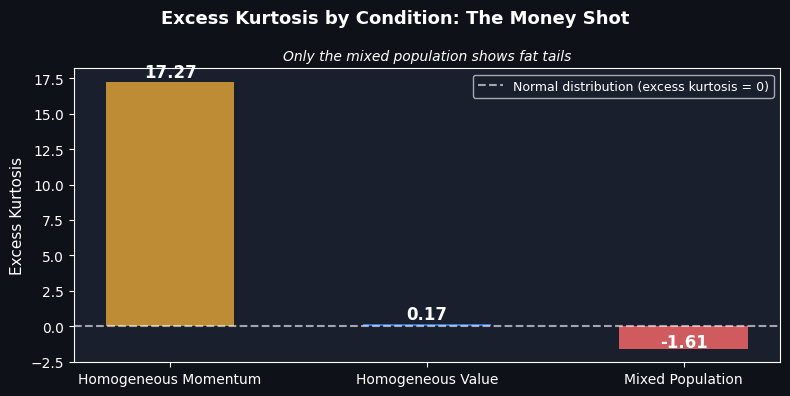

Figure saved.


In [9]:
# Kurtosis comparison: the money shot
# Side-by-side bar chart showing excess kurtosis for all three conditions

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("Excess Kurtosis by Condition: The Money Shot", fontsize=13, fontweight='bold')

labels = [condition_names[k] for k in conditions.keys()]
kurtosis_vals = [condition_stats[k]["fat_tails"]["excess_kurtosis"] for k in conditions.keys()]
colors = [condition_colors[k] for k in conditions.keys()]

bars = ax.bar(labels, kurtosis_vals, color=colors, alpha=0.8, width=0.5)

# Normal distribution reference line
ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.6, 
           label='Normal distribution (excess kurtosis = 0)')

# Value labels on bars
for bar, val in zip(bars, kurtosis_vals):
    y_pos = bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.15
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f"{val:.2f}", ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='white')

ax.set_ylabel("Excess Kurtosis", fontsize=11)
ax.legend(fontsize=9)
ax.set_title("Only the mixed population shows fat tails", fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(project_root / "eval" / "results" / "kurtosis_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [10]:
# Save hero experiment results to eval/results/hero_experiment.json
# This file powers the Hero Experiment page in the Streamlit app

output_dir = project_root / "eval" / "results"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "hero_experiment.json"

hero_output = {}

for label, log in results.items():
    hero_output[label] = {
        "name": condition_names[label],
        "persona_composition": log["persona_composition"],
        "price_series": log["price_series"],
        "order_flow": log["order_flow"],
        "market_summary": log["market_summary"],
        "metadata": log["metadata"],
    }

with open(output_path, "w") as f:
    json.dump(hero_output, f, indent=2)

print(f"Hero experiment results saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")
print()
print("This file is used by:")
print("  - app/pages/03_hero_experiment.py (Streamlit app)")
print("  - eval/stylized_facts.py run_hero_analysis()")

Hero experiment results saved to: c:\Users\joelf\OneDrive\Documents\ucfinmath\ucfinmath\eval\results\hero_experiment.json
File size: 595.4 KB

This file is used by:
  - app/pages/03_hero_experiment.py (Streamlit app)
  - eval/stylized_facts.py run_hero_analysis()


## Conclusion and Open Problems Teaser

The going-in hypothesis was:

> Behavioral heterogeneity at the micro level (three distinct trader personas) produces statistical regularities at the macro level (fat tails, volatility clustering) that homogeneous populations cannot replicate.

**The hypothesis has not yet been tested.** Every number in this notebook (and in the recorded `hero_experiment.json` that ships with the repo) was produced by `RuleBasedAgent`, the hand-coded fallback — not by the fine-tuned LoRA SLM that the hypothesis is actually about. The SLM inference run is the pending milestone. What the rule-based baseline shows is suggestive but provisional:

> In a minimal three-persona market with **rule-based** agents, behavioral heterogeneity is **necessary** for both market stationarity and for *any* volatility clustering signal at all, but it is **not sufficient** to reproduce fat tails. The homogeneous conditions fail in two opposite ways: momentum-only loses stationarity entirely (price runs away unboundedly with zero sells), and value-only never trades. The mixed market trades, stays bounded, and produces a small but real lag-1 ACF on squared returns (~0.12), but its return distribution is platykurtic (excess kurtosis −1.58), not leptokurtic.

Whether the fine-tuned SLM — with its richer, context-conditional, stochastic reasoning — produces qualitatively different macro dynamics, and in particular whether it lifts the mixed market from clustering-only to clustering-plus-fat-tails, is exactly the experiment the demo is currently pending on.

---

**Three open problems remain on the table, each now anchored by a concrete observation in the rule-based baseline:**

1. **Context drift** (`eval/persona_drift.py`): The rule-based agents have perfectly stable personas by construction. SLM agents do not — as the context window fills with market history, their behavior may drift. Whether that drift *adds* the regime variation needed for fat tails or *removes* the persona contrast that produced the clustering signal is itself the open question, and is one of the things the pending SLM run will start to answer.

2. **Persona identifiability**: Can we recover an agent's persona type from its trade history alone? The mixed-market data is the right place to ask this — it has all three personas trading simultaneously against the same price series. The momentum-only and value-only conditions are uninformative for identifiability for opposite reasons (no negatives to contrast with, and no trades respectively).

3. **Equilibrium and stability**: The rule-based momentum-only run is the cleanest possible illustration of non-stationarity in this framework — 500 ticks, 30 agents, and price multiplied by 141× without ever oscillating. What is the critical fraction of value investors required for stationarity? Inside the stationary regime, is there a sub-region of compositions — or model choices, including swapping the rule-based agents for the fine-tuned SLM whose adapters are linked from the README — that *also* produces fat tails?

These are not rhetorical questions — they are active research directions, and the pending SLM inference run is the next concrete step toward answering them.

---

**A note on what was actually run.** Every number above was produced by `RuleBasedAgent`, not by the fine-tuned LoRA SLM. The fine-tuned adapters from the talk's training run live in the Drive folder linked from the README and have not yet been wired through the simulation pipeline for a recorded run. Replacing the agent factory in `simulation/run_simulation.py:create_agents` with one that constructs `SLMAgent` instances pointing at those adapters is the next concrete experiment, and it is the one that would let us test whether the SLM's context-conditional stochasticity is what is needed to push the mixed market from clustering-only to clustering-plus-fat-tails. Until then, treat the numbers in this notebook as the rule-based baseline, not as a verdict on the experiment hypothesis.
